# Preprocessing FD002 & FD004 — Normalisation par condition

**Pourquoi normalisation par condition ?**
FD002 et FD004 ont 6 conditions opérationnelles différentes.
Un scaler global mélange toutes les conditions → le modèle prédit la moyenne.
Un scaler par condition → chaque condition est normalisée séparément → le modèle apprend les patterns de dégradation.

| | FD002 | FD004 |
|--|-------|-------|
| Conditions | 6 | 6 |
| Pannes | 1 | 2 |
| Moteurs | 260 | 248 |
| Features | 17 | 17 |

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
print(' Imports OK')

 Imports OK


In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/industrial-ai-platform'
DATA_DIR    = f'{BASE_DIR}/Data/cmapss'
CONFIG_PATH = f'{BASE_DIR}/feature_config.json'

# Dossiers output séparés
OUTPUT_FD002 = f'{BASE_DIR}/phase_preprocessing_FD002_v2'
OUTPUT_FD004 = f'{BASE_DIR}/phase_preprocessing_FD004_v2'

os.makedirs(OUTPUT_FD002, exist_ok=True)
os.makedirs(OUTPUT_FD004, exist_ok=True)

with open(CONFIG_PATH) as f:
    config = json.load(f)

SENSORS_TO_KEEP = config['sensors_to_keep']
SENSORS_TO_DROP = config['sensors_to_drop']
RUL_CAP         = config['rul_cap']   # 125
WINDOW_SIZE     = 30
SETTING_COLS    = ['op_setting_1', 'op_setting_2', 'op_setting_3']
FEATURE_COLS    = SENSORS_TO_KEEP + SETTING_COLS  # 17 features
N_FEATURES      = len(FEATURE_COLS)
N_CONDITIONS    = 6

print(f'Features : {N_FEATURES}')
print(f'Window   : {WINDOW_SIZE}')
print(f'RUL cap  : {RUL_CAP}')
print(f'Conditions : {N_CONDITIONS}')

Mounted at /content/drive
Features : 17
Window   : 30
RUL cap  : 125
Conditions : 6


## 2. Fonctions communes

In [3]:
COLUMNS = [
    'unit_id', 'time_cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    *[f'sensor_{i:02d}' for i in range(1, 22)]
]

def load_data(dataset_name):
    """Charger train, test, RUL pour un dataset."""
    df_train = pd.read_csv(f'{DATA_DIR}/train_{dataset_name}.txt',
                           sep=r'\s+', header=None, names=COLUMNS)
    df_test  = pd.read_csv(f'{DATA_DIR}/test_{dataset_name}.txt',
                           sep=r'\s+', header=None, names=COLUMNS)
    df_rul   = pd.read_csv(f'{DATA_DIR}/RUL_{dataset_name}.txt',
                           header=None, names=['RUL_true'])
    print(f'{dataset_name} — Train: {df_train.shape} | '
          f'Test: {df_test.shape} | '
          f'Moteurs: {df_train["unit_id"].nunique()}')
    return df_train, df_test, df_rul


def compute_rul(df_train, df_test, df_rul, rul_cap):
    """Calculer et plafonner le RUL."""
    # Train
    max_cycles = df_train.groupby('unit_id')['time_cycle'].max().rename('max_cycle')
    df_train   = df_train.merge(max_cycles, on='unit_id')
    df_train['RUL'] = df_train['max_cycle'] - df_train['time_cycle']
    df_train['RUL'] = df_train['RUL'].clip(upper=rul_cap)

    # Test
    test_max = df_test.groupby('unit_id')['time_cycle'].max().reset_index()
    test_max.columns = ['unit_id', 'max_cycle_test']
    df_test  = df_test.merge(test_max, on='unit_id')
    df_rul['unit_id'] = range(1, len(df_rul) + 1)
    df_test  = df_test.merge(df_rul, on='unit_id')
    df_test['RUL'] = df_test['RUL_true'] + (
        df_test['max_cycle_test'] - df_test['time_cycle']
    )
    df_test['RUL'] = df_test['RUL'].clip(upper=rul_cap)

    return df_train, df_test


def drop_columns(df_train, df_test, sensors_to_drop):
    """Supprimer les colonnes inutiles."""
    cols_to_drop = sensors_to_drop + ['max_cycle', 'max_cycle_test', 'RUL_true']
    df_train = df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns])
    df_test  = df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns])
    return df_train, df_test


def create_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            pad_y  = np.repeat(labels[0], window_size - T)
            labels = np.concatenate([pad_y, labels])
            T = window_size
        for t in range(T - window_size + 1):
            X_list.append(data[t : t + window_size])
            y_list.append(labels[t + window_size - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def create_test_sequences(df, feature_cols, window_size=30):
    X_list, y_list = [], []
    for unit_id, group in df.groupby('unit_id'):
        data   = group[feature_cols].values
        labels = group['RUL'].values
        T = len(data)
        if T < window_size:
            pad    = np.repeat(data[[0]], window_size - T, axis=0)
            data   = np.vstack([pad, data])
            labels = np.concatenate([
                np.repeat(labels[0], window_size - T), labels
            ])
        X_list.append(data[-window_size:])
        y_list.append(labels[-1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def save_files(X_train, y_train, X_test, y_test,
               unit_ids, output_dir, dataset_name):
    """Sauvegarder tous les fichiers .npy."""
    np.save(f'{output_dir}/X_train.npy',        X_train)
    np.save(f'{output_dir}/y_train.npy',        y_train)
    np.save(f'{output_dir}/X_test.npy',         X_test)
    np.save(f'{output_dir}/y_test.npy',         y_test)
    np.save(f'{output_dir}/unit_ids_train.npy', unit_ids)
    print(f'\n {dataset_name} — Fichiers sauvegardés :')
    for name in ['X_train','y_train','X_test','y_test','unit_ids_train']:
        path = f'{output_dir}/{name}.npy'
        size = os.path.getsize(path) / 1024
        print(f'  {name}.npy → {size:.1f} KB')


print(' Fonctions communes définies')

 Fonctions communes définies


## 3. Normalisation par condition — fonction principale

In [4]:
def normalize_by_condition(df_train, df_test, feature_cols,
                            setting_cols, n_conditions=6):
    """
    Normalisation par condition opérationnelle.

    Étapes :
    1. KMeans sur les settings → identifier les 6 conditions
    2. Pour chaque condition : fit scaler sur train → transform train + test
    3. Sauvegarder kmeans + scalers pour l'inférence
    """
    df_train = df_train.copy()
    df_test  = df_test.copy()

    # ── Étape 1 : KMeans sur les settings ─────────────────────
    kmeans = KMeans(n_clusters=n_conditions, random_state=42, n_init=10)
    df_train['condition'] = kmeans.fit_predict(df_train[setting_cols])
    df_test['condition']  = kmeans.predict(df_test[setting_cols])

    print(f'✅ KMeans — {n_conditions} conditions identifiées')
    print('Distribution conditions (train) :')
    print(df_train['condition'].value_counts().sort_index())

    # ── Étape 2 : Scaler par condition ────────────────────────
    scalers = {}
    sensors_only = [f for f in feature_cols if f not in setting_cols]

    for cond in range(n_conditions):
        mask_train = df_train['condition'] == cond
        mask_test  = df_test['condition']  == cond

        scaler = MinMaxScaler(feature_range=(0, 1))

        # Fit sur train uniquement
        df_train.loc[mask_train, sensors_only] = scaler.fit_transform(
            df_train.loc[mask_train, sensors_only]
        )
        # Transform sur test
        if mask_test.sum() > 0:
            df_test.loc[mask_test, sensors_only] = scaler.transform(
                df_test.loc[mask_test, sensors_only]
            )

        scalers[cond] = scaler
        print(f'  Condition {cond} → train:{mask_train.sum():,} | test:{mask_test.sum():,}')

    # Normaliser aussi les settings (0-1 globalement)
    setting_scaler = MinMaxScaler(feature_range=(0, 1))
    df_train[setting_cols] = setting_scaler.fit_transform(df_train[setting_cols])
    df_test[setting_cols]  = setting_scaler.transform(df_test[setting_cols])

    # Supprimer la colonne condition (pas une feature)
    df_train = df_train.drop(columns=['condition'])
    df_test  = df_test.drop(columns=['condition'])

    print('\n Normalisation par condition terminée')
    return df_train, df_test, kmeans, scalers, setting_scaler


print(' Fonction normalisation par condition définie')

 Fonction normalisation par condition définie


## 4. Preprocessing FD002

In [5]:
print('=' * 55)
print(' PREPROCESSING FD002')
print('=' * 55)

# Chargement
df_train_fd002, df_test_fd002, df_rul_fd002 = load_data('FD002')

# RUL
df_train_fd002, df_test_fd002 = compute_rul(
    df_train_fd002, df_test_fd002, df_rul_fd002, RUL_CAP
)

# Drop colonnes inutiles
df_train_fd002, df_test_fd002 = drop_columns(
    df_train_fd002, df_test_fd002, SENSORS_TO_DROP
)

print(f'\nShape train : {df_train_fd002.shape}')
print(f'Shape test  : {df_test_fd002.shape}')

 PREPROCESSING FD002
FD002 — Train: (53759, 26) | Test: (33991, 26) | Moteurs: 260

Shape train : (53759, 20)
Shape test  : (33991, 20)


In [6]:
# Normalisation par condition FD002
print(' Normalisation par condition FD002...')
df_train_fd002, df_test_fd002, kmeans_fd002, scalers_fd002, setting_scaler_fd002 = \
    normalize_by_condition(
        df_train_fd002, df_test_fd002,
        FEATURE_COLS, SETTING_COLS, N_CONDITIONS
    )

# Sauvegarder kmeans et scalers
joblib.dump(kmeans_fd002,         f'{OUTPUT_FD002}/kmeans_fd002.pkl')
joblib.dump(scalers_fd002,        f'{OUTPUT_FD002}/condition_scalers_fd002.pkl')
joblib.dump(setting_scaler_fd002, f'{OUTPUT_FD002}/setting_scaler_fd002.pkl')
print(' KMeans et scalers sauvegardés')

 Normalisation par condition FD002...
✅ KMeans — 6 conditions identifiées
Distribution conditions (train) :
condition
0    13458
1     8122
2     8002
3     8044
4     8096
5     8037
Name: count, dtype: int64
  Condition 0 → train:13,458 | test:8,483
  Condition 1 → train:8,122 | test:5,063
  Condition 2 → train:8,002 | test:5,042
  Condition 3 → train:8,044 | test:5,148
  Condition 4 → train:8,096 | test:5,107
  Condition 5 → train:8,037 | test:5,148

 Normalisation par condition terminée
 KMeans et scalers sauvegardés


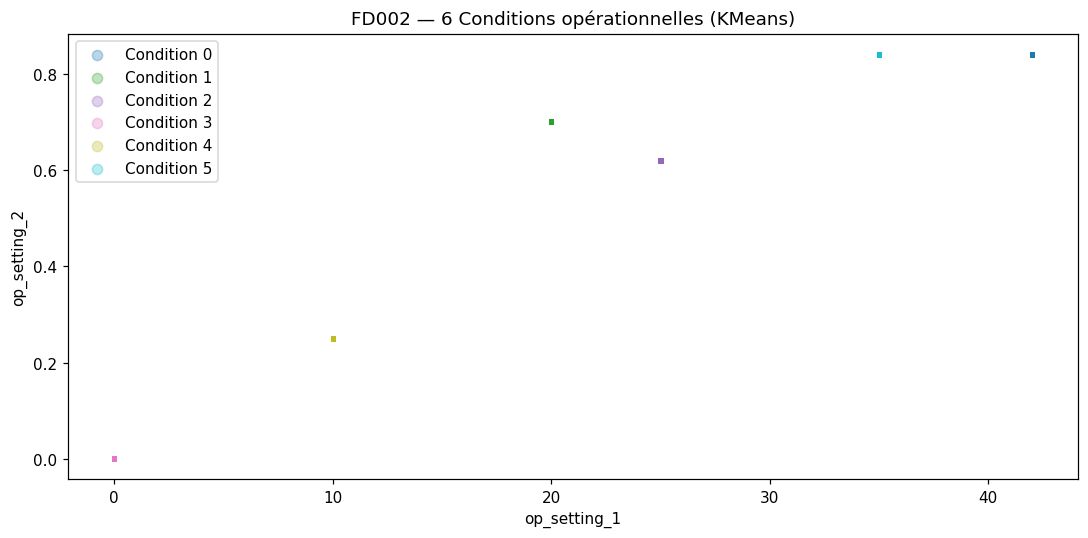

In [7]:
# Visualiser les 6 conditions FD002
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, N_CONDITIONS))

# Re-prédire les conditions pour visualisation
df_temp = pd.read_csv(f'{DATA_DIR}/train_FD002.txt',
                      sep=r'\s+', header=None, names=COLUMNS)
conds = kmeans_fd002.predict(df_temp[SETTING_COLS])

for cond in range(N_CONDITIONS):
    mask = conds == cond
    ax.scatter(df_temp.loc[mask, 'op_setting_1'],
               df_temp.loc[mask, 'op_setting_2'],
               c=[colors[cond]], label=f'Condition {cond}',
               alpha=0.3, s=5)

ax.set_title('FD002 — 6 Conditions opérationnelles (KMeans)', fontsize=12)
ax.set_xlabel('op_setting_1')
ax.set_ylabel('op_setting_2')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_FD002}/fd002_conditions.png', bbox_inches='tight')
plt.show()

In [8]:
# Fenêtres glissantes FD002
print(' Création des fenêtres FD002...')
X_train_fd002, y_train_fd002 = create_sequences(df_train_fd002, FEATURE_COLS, WINDOW_SIZE)
X_test_fd002,  y_test_fd002  = create_test_sequences(df_test_fd002, FEATURE_COLS, WINDOW_SIZE)

# Unit IDs
max_cycles = df_train_fd002.groupby('unit_id')['time_cycle'].max()
unit_ids_fd002 = []
for uid, cnt in max_cycles.items():
    unit_ids_fd002.extend([uid] * max(cnt - WINDOW_SIZE + 1, 1))
unit_ids_fd002 = np.array(unit_ids_fd002)

print(f'X_train : {X_train_fd002.shape}')
print(f'X_test  : {X_test_fd002.shape}')

# Sauvegarder
save_files(X_train_fd002, y_train_fd002, X_test_fd002, y_test_fd002,
           unit_ids_fd002, OUTPUT_FD002, 'FD002')

# Config
config_fd002 = {
    'dataset': 'FD002', 'n_features': N_FEATURES,
    'feature_cols': FEATURE_COLS, 'window_size': WINDOW_SIZE,
    'rul_cap': RUL_CAP, 'operating_conditions': N_CONDITIONS,
    'normalization': 'per_condition_kmeans',
    'n_train_engines': df_train_fd002['unit_id'].nunique(),
    'n_test_engines':  df_test_fd002['unit_id'].nunique()
}
with open(f'{OUTPUT_FD002}/config_FD002_v2.json', 'w') as f:
    json.dump(config_fd002, f, indent=2)
print('\n FD002 preprocessing v2 terminé !')

 Création des fenêtres FD002...
X_train : (46219, 30, 17)
X_test  : (259, 30, 17)

 FD002 — Fichiers sauvegardés :
  X_train.npy → 92077.0 KB
  y_train.npy → 180.7 KB
  X_test.npy → 516.1 KB
  y_test.npy → 1.1 KB
  unit_ids_train.npy → 361.2 KB

 FD002 preprocessing v2 terminé !


## 5. Preprocessing FD004

In [9]:
print('=' * 55)
print(' PREPROCESSING FD004')
print('=' * 55)

# Chargement
df_train_fd004, df_test_fd004, df_rul_fd004 = load_data('FD004')

# RUL
df_train_fd004, df_test_fd004 = compute_rul(
    df_train_fd004, df_test_fd004, df_rul_fd004, RUL_CAP
)

# Drop colonnes inutiles
df_train_fd004, df_test_fd004 = drop_columns(
    df_train_fd004, df_test_fd004, SENSORS_TO_DROP
)

print(f'\nShape train : {df_train_fd004.shape}')
print(f'Shape test  : {df_test_fd004.shape}')

 PREPROCESSING FD004
FD004 — Train: (61249, 26) | Test: (41214, 26) | Moteurs: 249

Shape train : (61249, 20)
Shape test  : (41214, 20)


In [10]:
# Normalisation par condition FD004
print(' Normalisation par condition FD004...')
df_train_fd004, df_test_fd004, kmeans_fd004, scalers_fd004, setting_scaler_fd004 = \
    normalize_by_condition(
        df_train_fd004, df_test_fd004,
        FEATURE_COLS, SETTING_COLS, N_CONDITIONS
    )

# Sauvegarder kmeans et scalers
joblib.dump(kmeans_fd004,         f'{OUTPUT_FD004}/kmeans_fd004.pkl')
joblib.dump(scalers_fd004,        f'{OUTPUT_FD004}/condition_scalers_fd004.pkl')
joblib.dump(setting_scaler_fd004, f'{OUTPUT_FD004}/setting_scaler_fd004.pkl')
print(' KMeans et scalers sauvegardés')

 Normalisation par condition FD004...
✅ KMeans — 6 conditions identifiées
Distribution conditions (train) :
condition
0    15395
1     9224
2     9139
3     9091
4     9238
5     9162
Name: count, dtype: int64
  Condition 0 → train:15,395 | test:10,382
  Condition 1 → train:9,224 | test:6,185
  Condition 2 → train:9,139 | test:6,107
  Condition 3 → train:9,091 | test:6,254
  Condition 4 → train:9,238 | test:6,054
  Condition 5 → train:9,162 | test:6,232

 Normalisation par condition terminée
 KMeans et scalers sauvegardés


In [11]:
# Fenêtres glissantes FD004
print(' Création des fenêtres FD004...')
X_train_fd004, y_train_fd004 = create_sequences(df_train_fd004, FEATURE_COLS, WINDOW_SIZE)
X_test_fd004,  y_test_fd004  = create_test_sequences(df_test_fd004, FEATURE_COLS, WINDOW_SIZE)

# Unit IDs
max_cycles = df_train_fd004.groupby('unit_id')['time_cycle'].max()
unit_ids_fd004 = []
for uid, cnt in max_cycles.items():
    unit_ids_fd004.extend([uid] * max(cnt - WINDOW_SIZE + 1, 1))
unit_ids_fd004 = np.array(unit_ids_fd004)

print(f'X_train : {X_train_fd004.shape}')
print(f'X_test  : {X_test_fd004.shape}')

# Sauvegarder
save_files(X_train_fd004, y_train_fd004, X_test_fd004, y_test_fd004,
           unit_ids_fd004, OUTPUT_FD004, 'FD004')

# Config
config_fd004 = {
    'dataset': 'FD004', 'n_features': N_FEATURES,
    'feature_cols': FEATURE_COLS, 'window_size': WINDOW_SIZE,
    'rul_cap': RUL_CAP, 'operating_conditions': N_CONDITIONS,
    'fault_modes': 2, 'normalization': 'per_condition_kmeans',
    'n_train_engines': df_train_fd004['unit_id'].nunique(),
    'n_test_engines':  df_test_fd004['unit_id'].nunique()
}
with open(f'{OUTPUT_FD004}/config_FD004_v2.json', 'w') as f:
    json.dump(config_fd004, f, indent=2)
print('\n FD004 preprocessing v2 terminé !')

 Création des fenêtres FD004...
X_train : (54028, 30, 17)
X_test  : (248, 30, 17)

 FD004 — Fichiers sauvegardés :
  X_train.npy → 107634.0 KB
  y_train.npy → 211.2 KB
  X_test.npy → 494.2 KB
  y_test.npy → 1.1 KB
  unit_ids_train.npy → 422.2 KB

 FD004 preprocessing v2 terminé !


## 6. Résumé Final

In [12]:
print('=' * 60)
print(' RÉSUMÉ PREPROCESSING v2 — Normalisation par condition')
print('=' * 60)
print(f'\nFD002 :')
print(f'  X_train : {X_train_fd002.shape}')
print(f'  X_test  : {X_test_fd002.shape}')
print(f'  Dossier : {OUTPUT_FD002}')
print(f'\nFD004 :')
print(f'  X_train : {X_train_fd004.shape}')
print(f'  X_test  : {X_test_fd004.shape}')
print(f'  Dossier : {OUTPUT_FD004}')
print('=' * 60)
print('\n Les deux datasets sont prêts pour l\'entraînement !')


 RÉSUMÉ PREPROCESSING v2 — Normalisation par condition

FD002 :
  X_train : (46219, 30, 17)
  X_test  : (259, 30, 17)
  Dossier : /content/drive/MyDrive/industrial-ai-platform/phase_preprocessing_FD002_v2

FD004 :
  X_train : (54028, 30, 17)
  X_test  : (248, 30, 17)
  Dossier : /content/drive/MyDrive/industrial-ai-platform/phase_preprocessing_FD004_v2

 Les deux datasets sont prêts pour l'entraînement !
